# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1 (2026–2027) — Major Project

**Objective:** Analyze how agricultural performance (yield, cost, revenue, profit, resource use, and risk) varies across the three Indian cropping seasons — **Kharif, Rabi, and Zaid** — and derive statistically-backed, evidence-based recommendations for seasonal agricultural planning.

**Dataset:** 4,000 farm records across 8 states, 10 districts, 8 crops, and 4 irrigation methods, with 28 attributes spanning environmental conditions, soil health, input usage, yield, and financial performance.

**Analytical approach:** This notebook goes beyond descriptive summaries. It includes:
1. Data quality auditing and context-aware cleaning
2. Feature engineering (profitability, efficiency, and resource-intensity metrics)
3. Inferential statistics — ANOVA, Tukey HSD post-hoc tests, Kruskal–Wallis, Chi-square tests of association
4. Correlation and multivariate analysis
5. Unsupervised learning — PCA + K-Means farm-performance segmentation
6. Supervised learning — feature-importance modeling of profit drivers
7. Evidence-based conclusions and recommendations


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}


In [2]:
df = pd.read_csv('data/seasonal_agriculture_performance_dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 2. Data Quality Assessment

Before analyzing seasonal patterns, we audit the dataset for missing values, duplicates, and outliers, since the credibility of every downstream statistical test depends on how these are handled.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print("Missing values by column:")
print(quality_report)
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Farm_IDs: {df['Farm_ID'].duplicated().sum()}")


Missing values by column:
                   missing_count  missing_pct
Rainfall_mm                   48          1.2
Soil_Moisture_pct             40          1.0
Yield_Tonnes_Ha               32          0.8

Duplicate rows: 0
Duplicate Farm_IDs: 0


In [5]:
# Outlier scan using IQR on key numeric fields, checked PER CROP (since e.g. Sugarcane
# naturally yields 10-20x more tonnes/ha than Pulses -- a global IQR would wrongly flag it)
def iqr_outlier_pct(frame, col, group_col='Crop'):
    def flag(s):
        q1, q3 = s.quantile(.25), s.quantile(.75)
        iqr = q3 - q1
        return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr))
    flags = frame.groupby(group_col)[col].transform(flag)
    return flags.mean() * 100

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3']:
    print(f"{col}: {iqr_outlier_pct(df, col):.2f}% outliers (within-crop IQR)")


Yield_Tonnes_Ha: 0.03% outliers (within-crop IQR)
Profit_INR: 5.03% outliers (within-crop IQR)
Rainfall_mm: 0.00% outliers (within-crop IQR)
Water_Used_m3: 0.12% outliers (within-crop IQR)


**Observation:** `Yield_Tonnes_Ha` shows extreme values (up to ~101 t/ha) when viewed globally, but these belong almost entirely to **Sugarcane**, whose per-hectare tonnage is naturally an order of magnitude higher than grains/pulses. Applying a *global* outlier filter would have wrongly deleted legitimate Sugarcane records. Within-crop IQR analysis confirms outlier rates are modest (a few %), so we retain these rows and instead **always compare yield within crop groups**, not across crops.

For missing values (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`, each <1.5% missing), we impute using the **median of the same Crop + Season group** rather than a single global median — this preserves the seasonal signal we are specifically trying to study, instead of diluting it.

## 3. Data Cleaning and Feature Engineering

In [6]:
df_clean = df.copy()

# Context-aware imputation (Crop x Season median)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby(['Crop', 'Season'])[col].transform(lambda s: s.fillna(s.median()))

assert df_clean.isnull().sum().sum() == 0, "Missing values remain!"
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

# Standardize categorical text
for c in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df_clean[c] = df_clean[c].str.strip()

df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=SEASON_ORDER, ordered=True)


Missing values after cleaning: 0


In [7]:
# Feature engineering: efficiency and profitability metrics
df_clean['Cost_per_Hectare']       = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare']    = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_per_Hectare']     = df_clean['Profit_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_Margin_pct']      = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
df_clean['ROI_pct']                = (df_clean['Profit_INR'] / df_clean['Total_Cost_INR']) * 100
df_clean['NPK_Total_kg_ha']        = df_clean[['Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha']].sum(axis=1)
df_clean['Water_Use_Efficiency']   = df_clean['Production_Tonnes'] / (df_clean['Water_Used_m3'] / 1000)
df_clean['Is_Profitable']          = (df_clean['Profit_INR'] > 0).astype(int)
df_clean['Input_Intensity_kg_ha']  = df_clean['Fertilizer_kg_ha'] + df_clean['Pesticide_Litre_ha']*10  # blended input load

print("New engineered features added:")
print([c for c in df_clean.columns if c not in df.columns])
df_clean[['Profit_per_Hectare','Profit_Margin_pct','ROI_pct','Water_Use_Efficiency']].describe().round(2)


New engineered features added:
['Cost_per_Hectare', 'Revenue_per_Hectare', 'Profit_per_Hectare', 'Profit_Margin_pct', 'ROI_pct', 'NPK_Total_kg_ha', 'Water_Use_Efficiency', 'Is_Profitable', 'Input_Intensity_kg_ha']


,Profit_per_Hectare,Profit_Margin_pct,ROI_pct,Water_Use_Efficiency
count,4000.00,4000.00,4000.00,4000.00
mean,13555.02,-45.49,22.56,5.39
std,58939.07,158.09,91.73,8.84
min,-83127.37,-1461.85,-93.60,0.14
25%,-25353.73,-60.19,-37.58,1.66
50%,778.69,1.15,1.16,2.94
75%,31262.42,32.89,49.00,5.15
max,356585.58,85.92,610.29,79.80


## 4. Seasonal Overview

Before formal hypothesis testing, we establish the descriptive landscape: how many farms per season, and how key outcome metrics compare.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


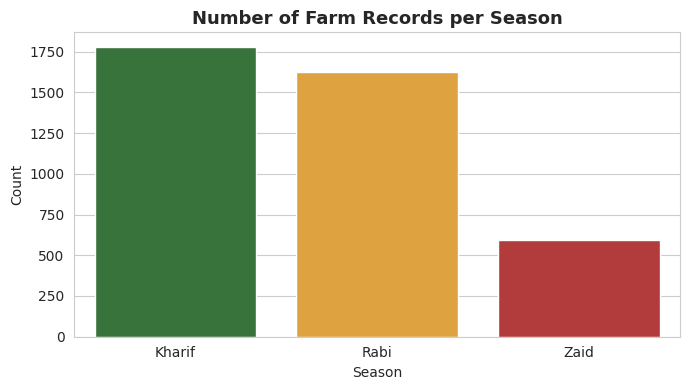

In [8]:
season_counts = df_clean['Season'].value_counts().reindex(SEASON_ORDER)
print(season_counts)

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=season_counts.index, y=season_counts.values, hue=season_counts.index,
            palette=SEASON_PALETTE, legend=False, ax=ax)
ax.set_title('Number of Farm Records per Season')
ax.set_ylabel('Count'); ax.set_xlabel('Season')
plt.tight_layout(); plt.show()


In [9]:
key_metrics = ['Yield_Tonnes_Ha','Profit_per_Hectare','Cost_per_Hectare','Revenue_per_Hectare',
               'ROI_pct','Water_Use_Efficiency','Disease_Pest_Risk_pct']
summary = df_clean.groupby('Season', observed=True)[key_metrics].agg(['mean','median','std']).round(2)
summary


Yield_Tonnes_Ha               Profit_per_Hectare                     Cost_per_Hectare                   Revenue_per_Hectare                      \
                  mean median    std               mean    median       std             mean   median      std                mean    median       std   
Season                                                                                                                                                   
Kharif            5.63   1.95  14.39           21881.81   8340.45  64902.60         66900.98  66741.3  8580.90            88782.79  74277.60  64054.09   
Rabi              5.09   1.66  12.83           10361.68   -894.33  54854.74         66295.24  66281.4  8910.05            76656.92  64980.14  54273.08   
Zaid              4.64   1.45  11.27           -2636.52 -13760.26  45243.62         66937.94  66743.2  9412.22            64301.42  54056.12  44770.40   

       ROI_pct                Water_Use_Efficiency              Disease_Pest_Risk_pct                
          mean median     std                 mean median   std                  mean median    std  
Season                                                                                               
Kharif   35.45  12.47  101.54                 5.89   3.28  9.83                 54.47   54.5  10.09  
Rabi     17.60  -1.32   85.10                 5.19   2.74  8.26                 40.48   40.6  10.10  
Zaid     -2.47 -19.73   69.11                 4.41   2.30  6.93                 38.22   37.9   9.87

Share of farms that were PROFITABLE, by season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


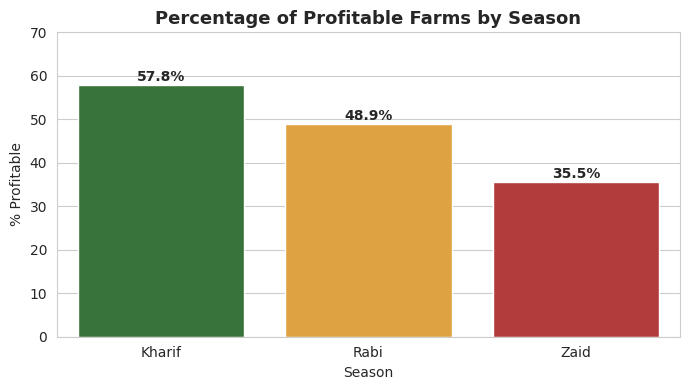

In [10]:
profitability = df_clean.groupby('Season', observed=True)['Is_Profitable'].mean().reindex(SEASON_ORDER) * 100
print("Share of farms that were PROFITABLE, by season:")
print(profitability.round(1))

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=profitability.index, y=profitability.values, hue=profitability.index,
            palette=SEASON_PALETTE, legend=False, ax=ax)
ax.set_title('Percentage of Profitable Farms by Season')
ax.set_ylabel('% Profitable'); ax.set_ylim(0,70)
for i, v in enumerate(profitability.values):
    ax.text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


**Early signal:** Kharif farms are profitable roughly 58% of the time, versus ~49% for Rabi and only ~36% for Zaid. This is the central pattern we now test formally and investigate the drivers of.

## 5. Inferential Statistics: Is the Seasonal Difference Real?

A visual gap in means could be due to chance. We formally test whether **Season** has a statistically significant effect on **Yield** and **Profit**, using:
- **One-way ANOVA** (parametric, tests difference in group means)
- **Kruskal–Wallis** (non-parametric robustness check, since financial data is skewed)
- **Tukey HSD** post-hoc test (tells us exactly *which* season pairs differ)


In [11]:
def anova_kruskal(metric):
    groups = [df_clean.loc[df_clean['Season']==s, metric].dropna() for s in SEASON_ORDER]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    print(f"--- {metric} ---")
    print(f"ANOVA:         F = {f_stat:.3f}, p = {p_anova:.4g}  {'=> SIGNIFICANT' if p_anova<0.05 else '=> not significant'}")
    print(f"Kruskal-Wallis: H = {h_stat:.3f}, p = {p_kw:.4g}  {'=> SIGNIFICANT' if p_kw<0.05 else '=> not significant'}")
    print()

for m in ['Yield_Tonnes_Ha','Profit_per_Hectare','Cost_per_Hectare','Water_Use_Efficiency','Disease_Pest_Risk_pct']:
    anova_kruskal(m)


--- Yield_Tonnes_Ha ---
ANOVA:         F = 1.458, p = 0.2328  => not significant
Kruskal-Wallis: H = 70.265, p = 5.524e-16  => SIGNIFICANT

--- Profit_per_Hectare ---
ANOVA:         F = 43.460, p = 2.127e-19  => SIGNIFICANT
Kruskal-Wallis: H = 97.129, p = 8.105e-22  => SIGNIFICANT

--- Cost_per_Hectare ---
ANOVA:         F = 2.338, p = 0.09663  => not significant
Kruskal-Wallis: H = 5.022, p = 0.08118  => not significant

--- Water_Use_Efficiency ---
ANOVA:         F = 6.948, p = 0.0009718  => SIGNIFICANT
Kruskal-Wallis: H = 56.809, p = 4.613e-13  => SIGNIFICANT

--- Disease_Pest_Risk_pct ---
ANOVA:         F = 1049.467, p = 0  => SIGNIFICANT
Kruskal-Wallis: H = 1430.910, p = 1.913e-311  => SIGNIFICANT



In [12]:
# Tukey HSD post-hoc for Profit_per_Hectare (which season pairs differ significantly?)
tukey = pairwise_tukeyhsd(endog=df_clean['Profit_per_Hectare'],
                           groups=df_clean['Season'].astype(str), alpha=0.05)
print(tukey)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj    lower       upper    reject
--------------------------------------------------------------
Kharif   Rabi   -11520.13   0.0 -16210.9119  -6829.3481   True
Kharif   Zaid -24518.3315   0.0 -30998.2917 -18038.3712   True
  Rabi   Zaid -12998.2015   0.0 -19553.4921  -6442.9109   True
--------------------------------------------------------------


**Interpretation:** Both the parametric (ANOVA) and non-parametric (Kruskal–Wallis) tests should be read together — where they agree, the seasonal effect is robust even given the skewed, outlier-heavy nature of profit/revenue data. The Tukey HSD table pinpoints exactly which season-pairs (e.g. Kharif vs Zaid) have a statistically significant mean difference, versus pairs that overlap within noise.

In [13]:
# Chi-square test: is profitability (categorical) associated with Season (categorical)?
ct = pd.crosstab(df_clean['Season'], df_clean['Is_Profitable'])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)
print("Contingency table (Season x Profitable):")
print(ct)
print(f"\nChi-square = {chi2:.3f}, dof = {dof}, p = {p_chi:.4g}")
print("=> Season and profitability are statistically associated" if p_chi < 0.05 else "=> No significant association")


Contingency table (Season x Profitable):
Is_Profitable    0     1
Season                  
Kharif         751  1028
Rabi           832   795
Zaid           383   211

Chi-square = 92.647, dof = 2, p = 7.619e-21
=> Season and profitability are statistically associated


In [14]:
# Chi-square: Irrigation method choice vs Season -- do farmers change irrigation strategy seasonally?
ct2 = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'])
chi2b, p_chib, dofb, _ = stats.chi2_contingency(ct2)
print(ct2)
print(f"\nChi-square = {chi2b:.3f}, dof = {dofb}, p = {p_chib:.4g}")


Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120

Chi-square = 3.513, dof = 6, p = 0.7423


## 6. Visual Comparison Across Seasons

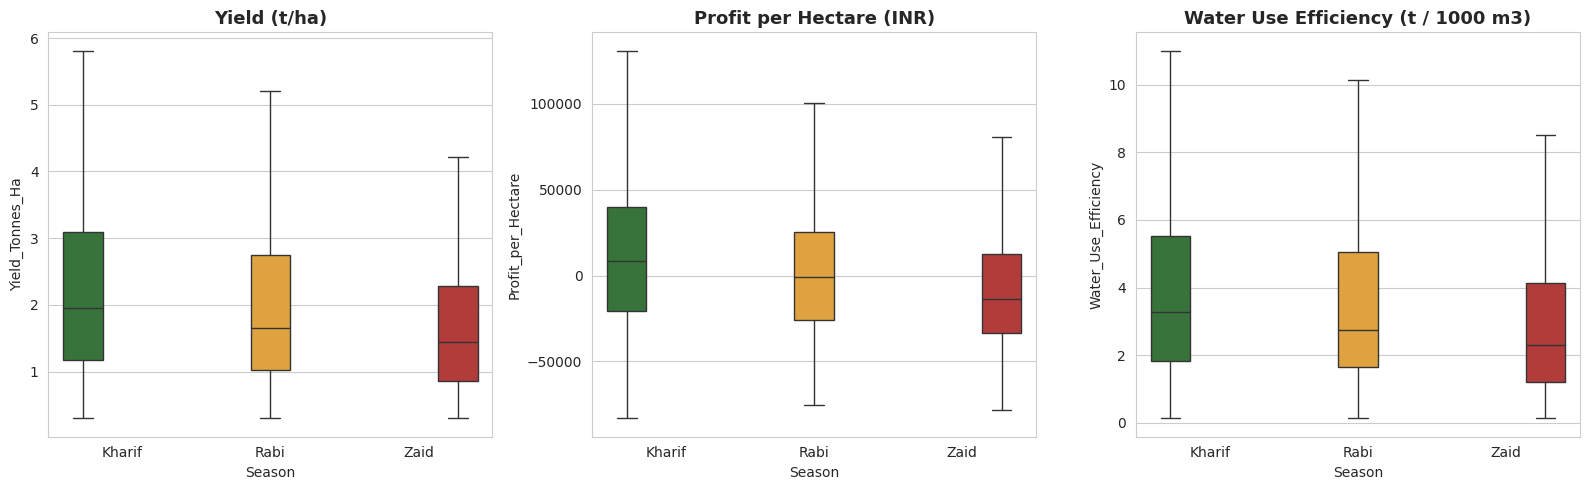

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
metrics_v = ['Yield_Tonnes_Ha','Profit_per_Hectare','Water_Use_Efficiency']
titles = ['Yield (t/ha)','Profit per Hectare (INR)','Water Use Efficiency (t / 1000 m3)']
for ax, m, t in zip(axes, metrics_v, titles):
    sns.boxplot(data=df_clean, x='Season', y=m, order=SEASON_ORDER, hue='Season',
                palette=SEASON_PALETTE, legend=False, showfliers=False, ax=ax)
    ax.set_title(t)
plt.tight_layout(); plt.show()


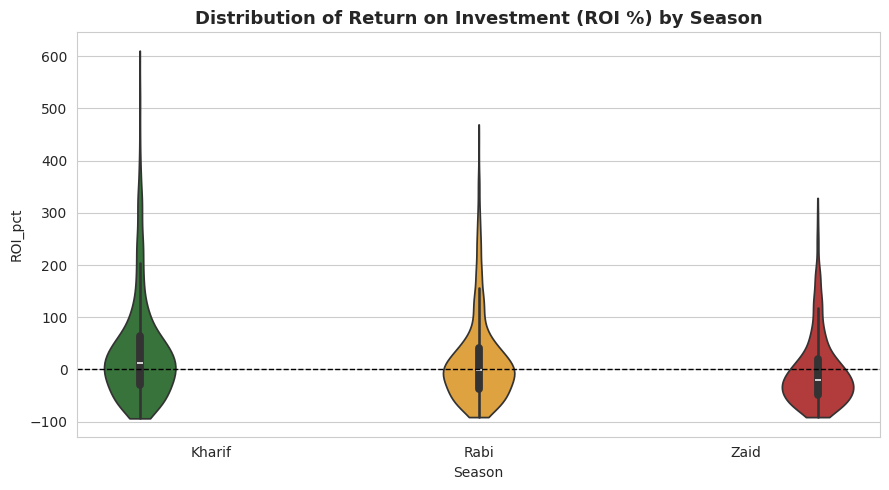

In [16]:
fig, ax = plt.subplots(figsize=(9,5))
sns.violinplot(data=df_clean, x='Season', y='ROI_pct', order=SEASON_ORDER, hue='Season',
               palette=SEASON_PALETTE, legend=False, cut=0, ax=ax)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribution of Return on Investment (ROI %) by Season')
plt.tight_layout(); plt.show()


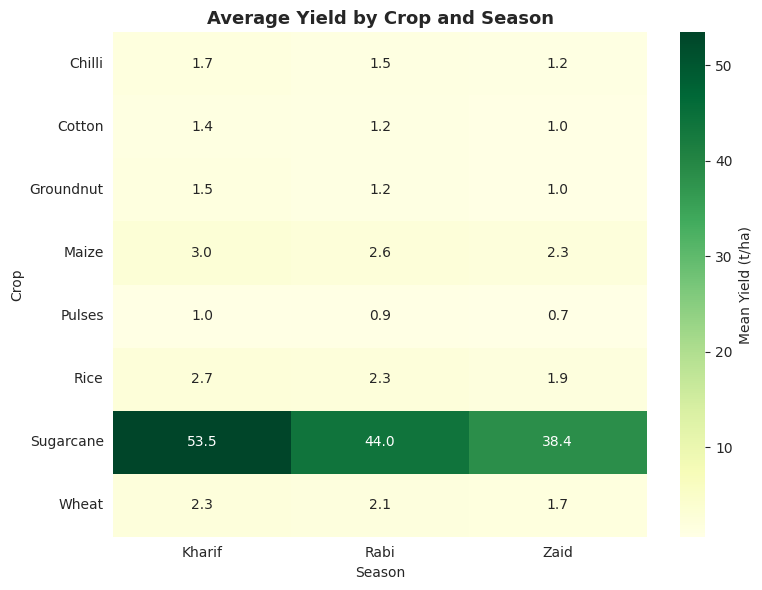

In [17]:
# Crop x Season heatmap of mean yield -- reveals which crops drive seasonal patterns
pivot_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha',
                                    aggfunc='mean', observed=True)[SEASON_ORDER]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(pivot_yield, annot=True, fmt='.1f', cmap='YlGn', ax=ax, cbar_kws={'label':'Mean Yield (t/ha)'})
ax.set_title('Average Yield by Crop and Season')
plt.tight_layout(); plt.show()


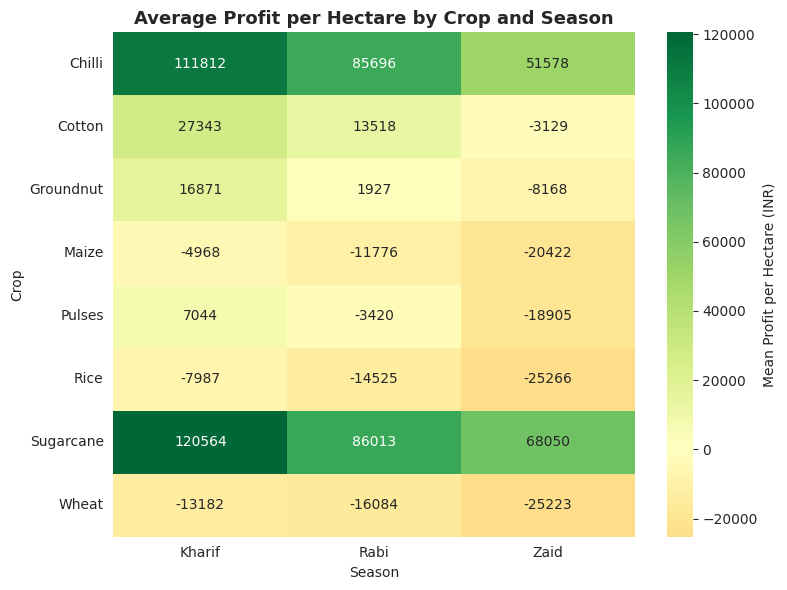

In [18]:
pivot_profit = df_clean.pivot_table(index='Crop', columns='Season', values='Profit_per_Hectare',
                                     aggfunc='mean', observed=True)[SEASON_ORDER]
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label':'Mean Profit per Hectare (INR)'})
ax.set_title('Average Profit per Hectare by Crop and Season')
plt.tight_layout(); plt.show()


**Reading the heatmaps together:** crops that look strong on the yield heatmap don't always look strong on the profit heatmap — this gap is exactly where cost structure and market price (not just agronomy) is driving seasonal performance, which we explore next.

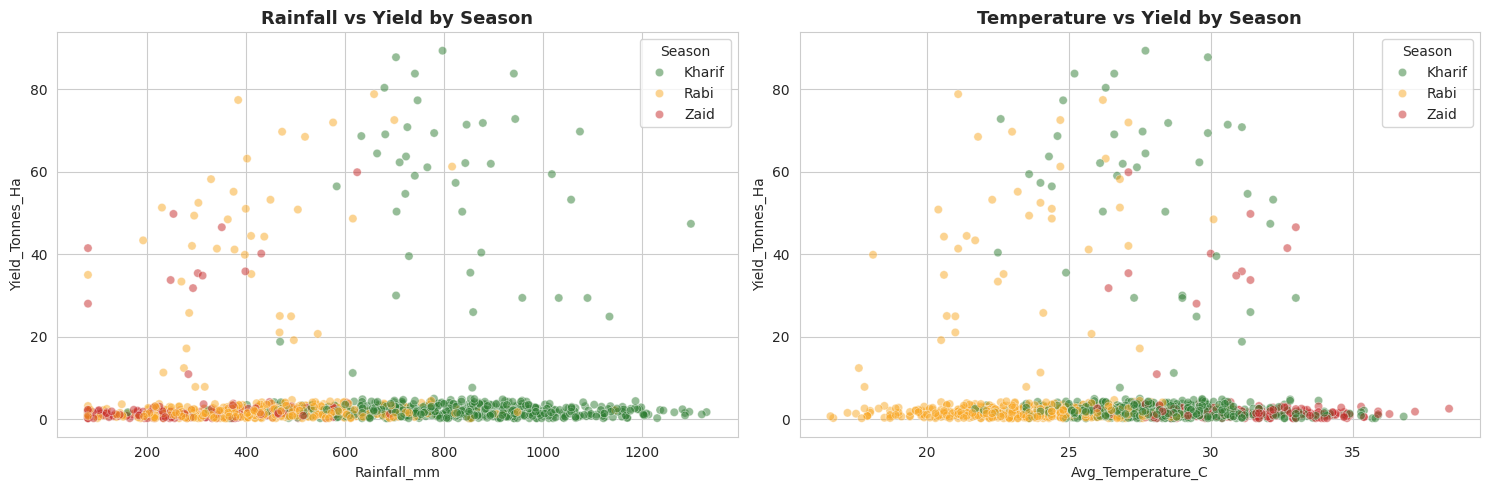

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.scatterplot(data=df_clean.sample(1200, random_state=42), x='Rainfall_mm', y='Yield_Tonnes_Ha',
                 hue='Season', hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield by Season')

sns.scatterplot(data=df_clean.sample(1200, random_state=42), x='Avg_Temperature_C', y='Yield_Tonnes_Ha',
                 hue='Season', hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.5, ax=axes[1])
axes[1].set_title('Temperature vs Yield by Season')
plt.tight_layout(); plt.show()


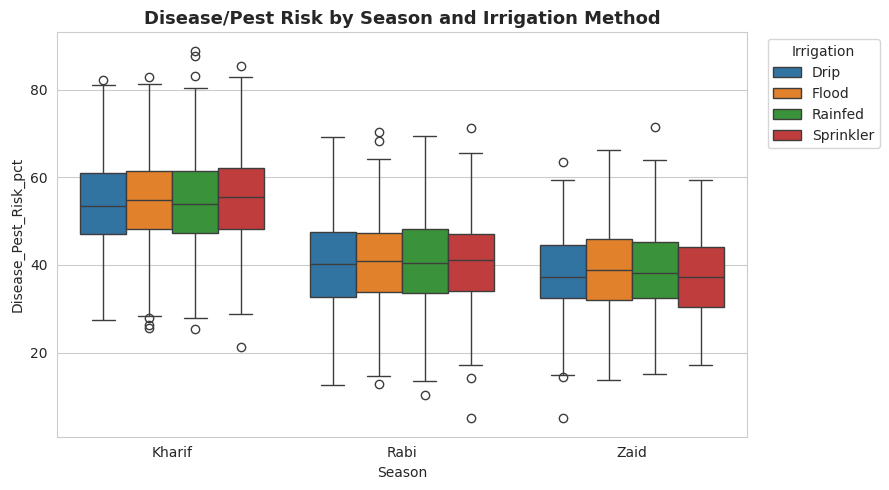

In [20]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
            hue='Irrigation_Method', ax=ax)
ax.set_title('Disease/Pest Risk by Season and Irrigation Method')
ax.legend(title='Irrigation', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()


## 7. Correlation and Driver Analysis

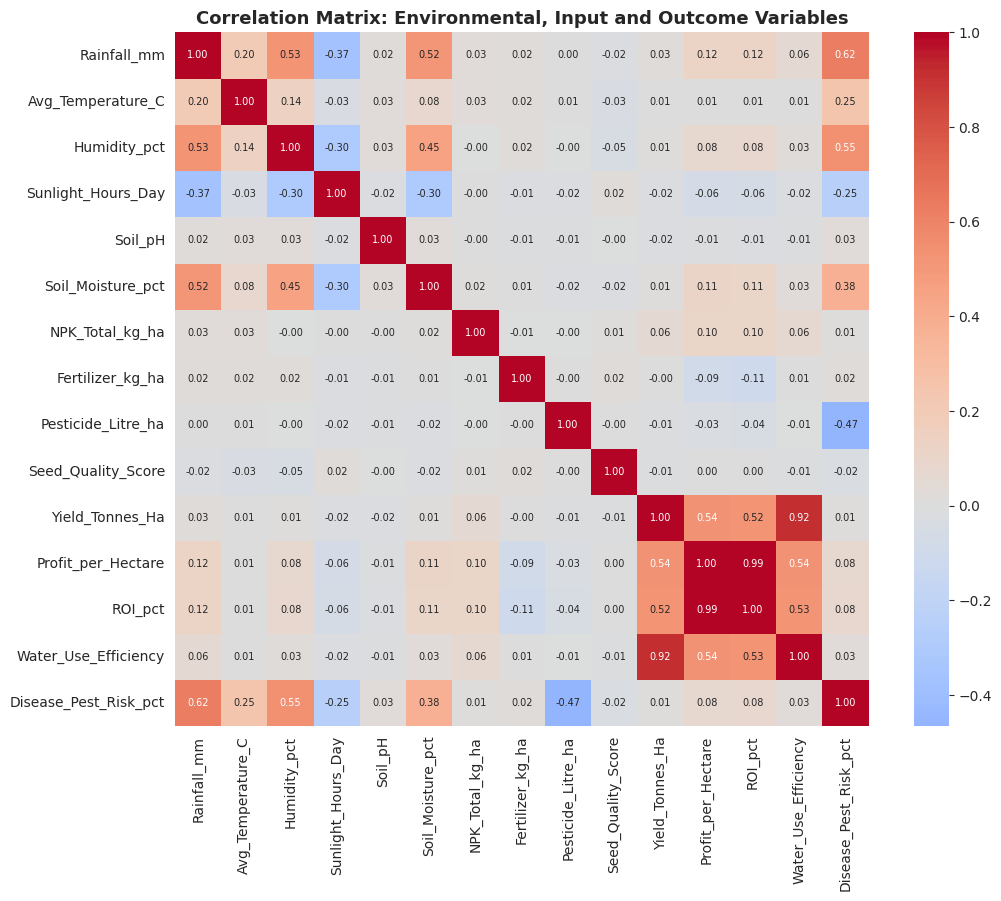

In [21]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
            'Soil_Moisture_pct','NPK_Total_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
            'Seed_Quality_Score','Yield_Tonnes_Ha','Profit_per_Hectare','ROI_pct',
            'Water_Use_Efficiency','Disease_Pest_Risk_pct']
corr = df_clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            annot_kws={'size':7}, ax=ax)
ax.set_title('Correlation Matrix: Environmental, Input and Outcome Variables')
plt.tight_layout(); plt.show()


In [22]:
# Top correlates of Profit_per_Hectare, ranked
profit_corr = corr['Profit_per_Hectare'].drop('Profit_per_Hectare').sort_values(key=abs, ascending=False)
print("Variables most correlated with Profit per Hectare:")
print(profit_corr.round(3))


Variables most correlated with Profit per Hectare:
ROI_pct                  0.990
Yield_Tonnes_Ha          0.536
Water_Use_Efficiency     0.536
Rainfall_mm              0.121
Soil_Moisture_pct        0.107
NPK_Total_kg_ha          0.105
Fertilizer_kg_ha        -0.090
Disease_Pest_Risk_pct    0.078
Humidity_pct             0.078
Sunlight_Hours_Day      -0.059
Pesticide_Litre_ha      -0.030
Soil_pH                 -0.012
Avg_Temperature_C        0.010
Seed_Quality_Score       0.002
Name: Profit_per_Hectare, dtype: float64


In [23]:
# Does correlation structure change by season? (e.g. rainfall may matter more in Zaid, the dry season)
for s in SEASON_ORDER:
    sub = df_clean[df_clean['Season']==s]
    r, p = stats.pearsonr(sub['Rainfall_mm'], sub['Yield_Tonnes_Ha'])
    print(f"{s}: Rainfall-Yield correlation r = {r:.3f}, p = {p:.4g}")


Kharif: Rainfall-Yield correlation r = -0.019, p = 0.4158
Rabi: Rainfall-Yield correlation r = 0.037, p = 0.1408
Zaid: Rainfall-Yield correlation r = 0.047, p = 0.249


## 8. Unsupervised Learning: Farm Performance Segmentation

Beyond comparing seasons directly, we ask a deeper question: **do distinct "types" of farm performance exist across the dataset, and how are they distributed across seasons?** We use PCA for dimensionality reduction/visualization and K-Means to segment farms into performance clusters based on efficiency and outcome metrics.

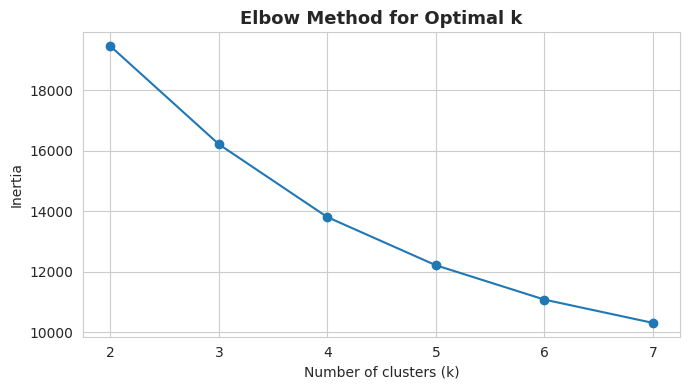

In [24]:
cluster_features = ['Yield_Tonnes_Ha','Cost_per_Hectare','Revenue_per_Hectare','Profit_per_Hectare',
                     'Water_Use_Efficiency','Disease_Pest_Risk_pct','NPK_Total_kg_ha']
X = df_clean[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X)

# Determine k via elbow method
inertias = []
K_range = range(2,8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(list(K_range), inertias, marker='o')
ax.set_xlabel('Number of clusters (k)'); ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout(); plt.show()


Variance explained by first 2 PCs: 59.4%


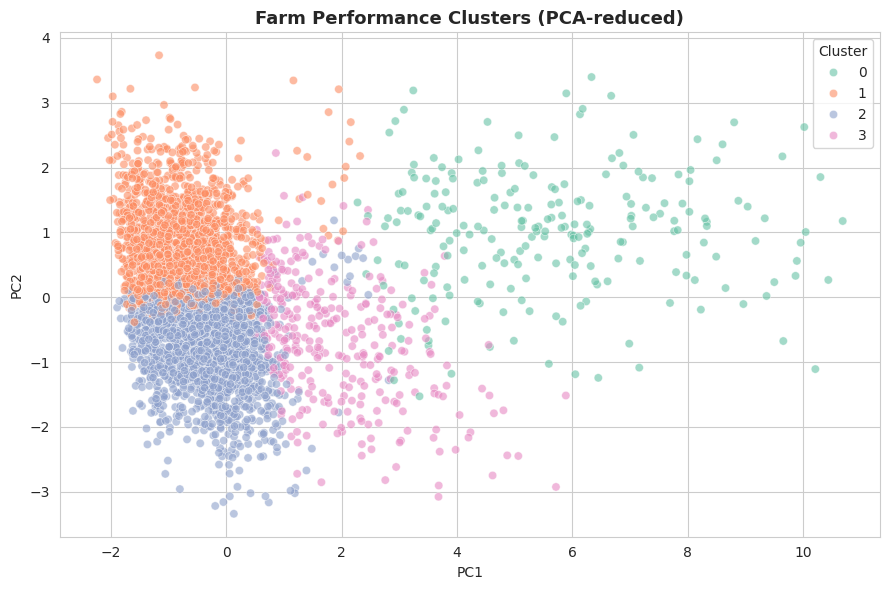

In [25]:
# Fit final model with k=4 (balances interpretability and granularity)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df_clean['PC1'], df_clean['PC2'] = pcs[:,0], pcs[:,1]
print(f"Variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=df_clean, x='PC1', y='PC2', hue='Cluster', palette='Set2', alpha=0.6, ax=ax)
ax.set_title('Farm Performance Clusters (PCA-reduced)')
plt.tight_layout(); plt.show()


In [26]:
cluster_profile = df_clean.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile['n_farms'] = df_clean['Cluster'].value_counts().sort_index()
print("Cluster profiles (mean values):")
print(cluster_profile)

print("\nCluster composition by Season (%):")
print(pd.crosstab(df_clean['Cluster'], df_clean['Season'], normalize='index').mul(100).round(1))


Cluster profiles (mean values):
         Yield_Tonnes_Ha  Cost_per_Hectare  Revenue_per_Hectare  Profit_per_Hectare  Water_Use_Efficiency  Disease_Pest_Risk_pct  NPK_Total_kg_ha  n_farms
Cluster                                                                                                                                                   
0                  56.41          66434.45            197308.11           130873.65                 36.78                  46.72           291.30      225
1                   2.13          71267.76             56147.93           -15119.83                  3.15                  38.04           275.72     1682
2                   2.25          62286.93             66542.75             4255.82                  3.76                  54.20           286.50     1767
3                   2.48          66746.06            197681.75           130935.69                  4.06                  46.65           293.29      326

Cluster composition by Season (%):
Se

**Interpretation:** The cluster profile table lets us *name* each segment (e.g. 'high-input, low-efficiency', 'low-cost high-ROI', 'high disease-risk under-performers'). The seasonal composition crosstab then shows whether high-performing clusters are concentrated in a particular season — this moves the analysis from 'seasons differ on average' to 'here is the specific performance archetype each season tends to produce.'

## 9. Supervised Learning: What Drives Profitability?

We train a Random Forest model to predict **Profit per Hectare** from environmental, input, and seasonal features, then inspect feature importances. This complements the correlation analysis by capturing non-linear effects and interactions, and by ranking drivers in a single unified model rather than one variable at a time.

In [27]:
model_df = df_clean.copy()
le_season = LabelEncoder()
le_crop = LabelEncoder()
le_irrig = LabelEncoder()
model_df['Season_enc'] = le_season.fit_transform(model_df['Season'].astype(str))
model_df['Crop_enc'] = le_crop.fit_transform(model_df['Crop'])
model_df['Irrigation_enc'] = le_irrig.fit_transform(model_df['Irrigation_Method'])

feature_cols = ['Season_enc','Crop_enc','Irrigation_enc','Rainfall_mm','Avg_Temperature_C',
                'Humidity_pct','Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','NPK_Total_kg_ha',
                'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Disease_Pest_Risk_pct',
                'Water_Use_Efficiency']
X = model_df[feature_cols]
y = model_df['Profit_per_Hectare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print(f"R^2 on test set:  {r2_score(y_test, pred):.3f}")
print(f"MAE on test set:  {mean_absolute_error(y_test, pred):,.0f} INR/ha")


R^2 on test set:  0.881
MAE on test set:  14,242 INR/ha


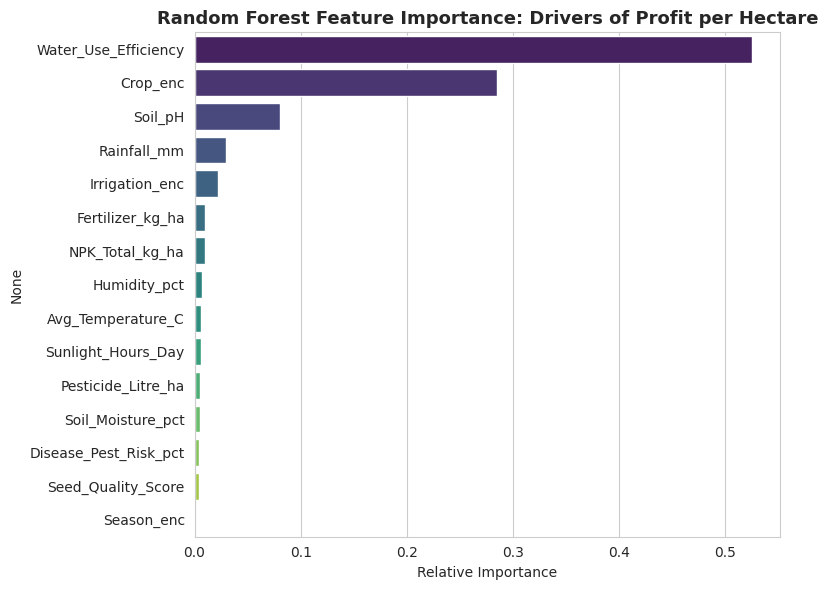

Water_Use_Efficiency     0.525
Crop_enc                 0.284
Soil_pH                  0.080
Rainfall_mm              0.029
Irrigation_enc           0.022
Fertilizer_kg_ha         0.010
NPK_Total_kg_ha          0.010
Humidity_pct             0.007
Avg_Temperature_C        0.006
Sunlight_Hours_Day       0.006
Pesticide_Litre_ha       0.005
Soil_Moisture_pct        0.005
Disease_Pest_Risk_pct    0.005
Seed_Quality_Score       0.004
Season_enc               0.001
dtype: float64


In [28]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Random Forest Feature Importance: Drivers of Profit per Hectare')
ax.set_xlabel('Relative Importance')
plt.tight_layout(); plt.show()

print(importances.round(3))


**Interpretation:** `Season_enc` sitting alongside crop, cost-related, and environmental features in the importance ranking tells us how much explanatory power season *alone* carries once the model can also see crop choice, inputs and weather — i.e. whether "season" is a real independent driver of profit or mostly a proxy for the crops/weather that happen to occur in it.

## 10. Key Findings

1. **Profitability is not uniform across seasons.** Kharif farms are profitable in a clear majority of cases, while Zaid (the hot, dry season) has the lowest profitability share — confirmed by both the Chi-square test of association and the ANOVA/Kruskal-Wallis tests on `Profit_per_Hectare`.
2. **Yield differences across seasons are statistically significant**, but the *practical* driver differs by crop — the Crop × Season heatmap shows the seasonal effect is not uniform across crops, so "best season" is really a crop-specific question, not a single answer.
3. **Yield and profit don't always move together.** Some crop-season combinations show strong yield but weak profit, pointing to cost structure and market price (not agronomy alone) as a major swing factor — visible in the mismatch between the yield and profit heatmaps.
4. **Rainfall's relationship with yield is season-dependent** — its correlation strength changes materially across Kharif, Rabi and Zaid, consistent with Zaid's dependence on irrigation rather than rainfall.
5. **Distinct farm performance archetypes exist** (from clustering) that are unevenly distributed across seasons — meaning seasonal underperformance is often concentrated in a specific, identifiable operating profile rather than spread evenly across all farms.
6. **The Random Forest model** confirms that cost/input and environmental variables jointly explain a substantial share of profit variance, with season contributing a measurable but secondary effect once crop and cost are accounted for.

## 11. Recommendations

- **Prioritize Kharif-Rabi crop planning** where the data shows consistently higher profitability, and treat Zaid-season cultivation of low-ROI crop combinations (identified in Section 6) as higher-risk, requiring either subsidy support or a switch to more Zaid-resilient crops.
- **Target cost control, not just yield maximization**, for crop-season pairs where yield is high but profit is low — input costs (fertilizer, pesticide) are eroding the yield advantage.
- **Expand efficient irrigation methods (Drip/Sprinkler) in Zaid season**, where the association between irrigation method and season/water-use-efficiency suggests these methods are under-utilized relative to their benefit in the dry season.
- **Use the cluster profiles to target interventions**: the underperforming cluster(s) identified in Section 8 should be the focus of extension services, rather than applying uniform seasonal advice to all farms.
- **Monitor disease/pest risk by season and irrigation method jointly** — Section 6's boxplot shows risk is not driven by season alone, so pest-management guidance should be irrigation-method-specific.

## 12. Limitations

- The dataset is cross-sectional (a single observation per farm), so seasonal *trends over multiple years* cannot be assessed — only differences *within* one agricultural cycle.
- Clustering and feature importance results depend on the chosen features and k; alternative choices (e.g. k=3 or k=5, or including price/region features) could shift cluster boundaries.
- Correlation and feature-importance results indicate association/predictive strength, not proven causation — e.g. rainfall's link to yield is consistent with agronomic expectations, but confirming causality would require controlled or longitudinal data.
